Going to use the Dynamic Mean Field (DMF) neuronal model...
Going to use the serotonin 2A receptor (5-HT_{2A}R) transfer WholeBrain!
Going to use the Euler-Maruyama Integrator...
Going to use Stephan2007 BOLD model...
Going to use the Balanced J9 (FIC) mechanism...
Going to use the FIC mechanism in DecoEtAl2014...
Going to use a matrix distance measure...
Going to use Functional Connectivity (FC)...
Going to use Sliding Windows Functional Connectivity Dynamics (swFCD)...
Loading ./all_SC_FC_TC_76_90_116.mat
Loading ./mean5HT2A_bindingaal.mat
Loading ./LSDnew_sub1.mat
tc_aal is (1, 6) and each entry has N=90 regions and Tmax=220
Simulating 1 subjects!
inFilePath = .
outFilePath = out4
C shape = (90, 90)
NumSubjects = 1
Loading file (@loadOrCompute): out4/J_Balance_we0.0.mat !!!
Loading file (@loadOrCompute): out4/J_Balance_we0.3.mat !!!
Loading file (@loadOrCompute): out4/J_Balance_we0.6.mat !!!
Loading file (@loadOrCompute): out4/J_Balance_we0.9.mat !!!
Loading file (@loadOrCompute): o

/Users/zixuan.zhouchildmind.org/Documents/2025/VB/DMFs/Papers-Data/Deco2018/WholeBrain/Integrators/EulerMaruyama.py:36: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 1, 'C', False, aligned=True))
  dvars_obsVars = neuronalModel.dfun(simVars, coupling, stimulus)


0(0) New min!!!, 1(0), 2(0), 3(80) New min!!!, 4(66), 5(78), 6(67), 7(56), 8(88) New min!!!, 9(58), 10(84), 11(65), 12(71), 13(70), 14(76), 15(22), 16(67), 17(71), 18(79), 19(73), 20(64), 21(76), 22(61), 23(76), 24(86), 25(79), 26(76), 27(69), 28(69), 29(64), 30(83), 31(72), 32(69), 33(48), 34(77), 35(86), 36(1), 37(84), 38(80), 39(66), 40(88), 41(40), 42(65), 43(64), 44(86), 45(66), 46(77), 47(73), 48(73), 49(62), 50(35), 51(83), 52(44), 53(47), 54(90) New min!!!Out !!!
Final (we=2.1): 54 trials, with 90/90 nodes solved at trial 54
DONE!
Computing (@loadOrCompute): out4/J_Balance_we2.4.mat
Balancing for we=2.4
(using N optim)
  Trials: 0(0) New min!!!, 1(0), 2(0), 3(25) New min!!!, 4(0), 5(0), 6(0), 7(0), 8(0), 9(0), 10(0), 11(0), 12(0), 13(0), 14(0), 15(0), 16(0), 17(0), 18(0), 19(0), 20(0), 21(0), 22(0), 23(0), 24(0), 25(0), 26(9), 27(3), 28(2), 29(12), 30(18), 31(19), 32(48) New min!!!, 33(11), 34(41), 35(41), 36(28), 37(61) New min!!!, 38(60), 39(18), 40(44), 41(63) New min!!!, 42

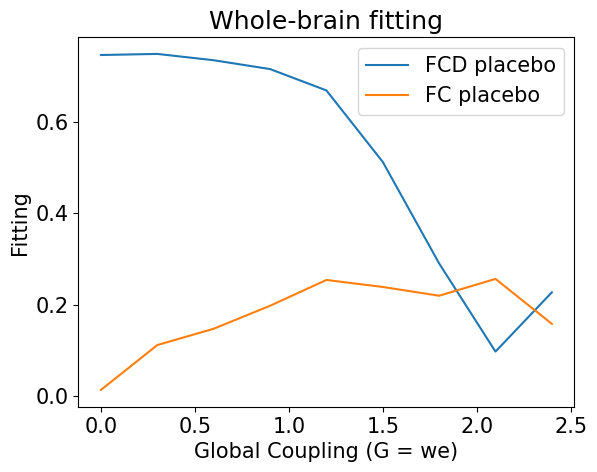

In [1]:
import matplotlib.pyplot as plt

from my_setup import *
print("inFilePath =", inFilePath)
print("outFilePath =", outFilePath)
print("C shape =", C.shape)
print("NumSubjects =", NumSubjects)

filePath = outFilePath + '/DecoEtAl2018_fneuro.mat'
if not Path(filePath).is_file():
    import my_prepro as prepro
    prepro.prepro_G_Optim()

fNeuro = sio.loadmat(filePath)
WEs = fNeuro['we'].flatten()
fitting_PLA = fNeuro['fitting_PLA'].flatten()
FCDfitt_PLA = fNeuro['FCDfitt_PLA'].flatten()

maxFC = WEs[np.argmax(fitting_PLA)]
minFCD = WEs[np.argmin(FCDfitt_PLA)]
print(f"Max FC at we={maxFC}: {np.max(fitting_PLA)}")
print(f"Min FCD at we={minFCD}: {np.min(FCDfitt_PLA)}")

plt.rcParams.update({'font.size': 15})
plt.plot(WEs, FCDfitt_PLA, label="FCD placebo")
plt.plot(WEs, fitting_PLA, label="FC placebo")
plt.title("Whole-brain fitting")
plt.ylabel("Fitting")
plt.xlabel("Global Coupling (G = we)")
plt.legend()
plt.show()

Loading file (@loadOrCompute): out4/J_Balance_we2.1.mat !!!


*************** Starting: optim1D.distanceForAll_Parms *****************


tc(1 subjects): each entry has N=90 regions
Computing (@loadOrCompute): out4/fNeuro_emp_PLA.mat
   Processing signal 1/1 Subject: 0 (90x220) -> computed in 0.49286066700005904 seconds


 ====================== Model Simulations ======================


Computing (@loadOrCompute): out4/fitting_S_E0.0_PLA.mat
   --- BEGIN TIME @ S_E=0.0 ---
   Simulating S_E=0.0 -> subject 0/1!!!
   Processing signal 1/1 Subject: 0 (90x210) -> computed in 0.3328623330453411 seconds
   --- TOTAL TIME: 48.65259700000752 seconds ---
#0/1: swFCD: 0.2961410411622276;

Computing (@loadOrCompute): out4/fitting_S_E0.02_PLA.mat
   --- BEGIN TIME @ S_E=0.02 ---
   Simulating S_E=0.02 -> subject 0/1!!!
   Processing signal 1/1 Subject: 0 (90x210) -> computed in 0.33377595798810944 seconds
   --- TOTAL TIME: 48.210588750022 seconds ---
#1/1: swFCD: 0.20148977670164112;

Computing (

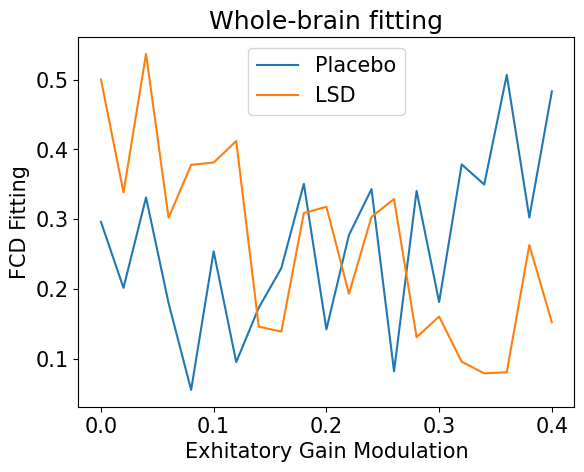

In [2]:
import my_fgain as fgain
fgain.fitting_ModelParms(tc_transf_PLA, '_PLA')
fgain.fitting_ModelParms(tc_transf_LSD, '_LSD')

def load_fitting(suffix):
    fp = outFilePath + f'/DecoEtAl2018_fitting{suffix}.mat'
    print("Loading", fp)
    d = sio.loadmat(fp)
    return d['S_E'].flatten(), d['fitting_FCD'].flatten()

S_E_PLA, fit_PLA = load_fitting('_PLA')
S_E_LSD, fit_LSD = load_fitting('_LSD')

minPLA = S_E_PLA[np.argmin(fit_PLA)]
minLSD = S_E_LSD[np.argmin(fit_LSD)]
print(f"Placebo min at S_E={minPLA}: {np.min(fit_PLA)}")
print(f"LSD min at S_E={minLSD}: {np.min(fit_LSD)}")

plt.rcParams.update({'font.size': 15})
plt.plot(S_E_PLA, fit_PLA, label="Placebo")
plt.plot(S_E_LSD, fit_LSD, label="LSD")
plt.title("Whole-brain fitting")
plt.ylabel("FCD Fitting")
plt.xlabel("Exhitatory Gain Modulation")
plt.legend()
plt.show()

Condition: 1
  Subject: 0
Condition: 4
  Subject: 0
Saving out4/FCD_values_Empirical.mat


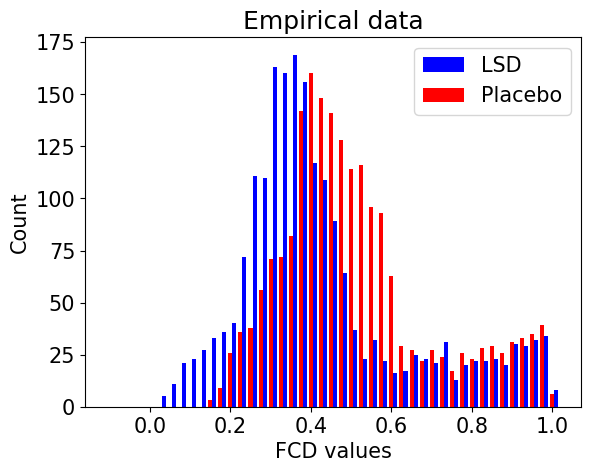

In [3]:
def my_hist(x, bin_centers):
    bin_edges = np.r_[-np.Inf, 0.5 * (bin_centers[:-1] + bin_centers[1:]), np.Inf]
    counts, _ = np.histogram(x, bin_edges)
    return counts, bin_centers

Conditions = [LSD_cond, PLACEBO_cond]

# Determine FCD vector length from first available subject/condition
cot0 = swFCD.from_fMRI(tc_aal[0, Conditions[0]])
cot_len = np.asarray(cot0).size
cotsampling = np.zeros((len(Conditions), NumSubjects, cot_len))

for task, cond in enumerate(Conditions):
    print("Condition:", cond)
    for s in range(NumSubjects):
        print("  Subject:", s)
        signal = tc_aal[s, cond]
        cotsampling[task, s, :] = swFCD.from_fMRI(signal)

fileName = outFilePath + '/FCD_values_Empirical.mat'
print("Saving", fileName)
sio.savemat(fileName, {'cotsampling': cotsampling})

bins = np.arange(-.1, 1.025, .025)
h_lsd, x = my_hist(cotsampling[0, :].T.flatten(), bins)
h_pla, _ = my_hist(cotsampling[1, :].T.flatten(), bins)

width = 0.01
plaBar = plt.bar(x, h_pla, width=width, color="red", label="Placebo")
lsdBar = plt.bar(x + width, h_lsd, width=width, color="blue", label="LSD")
plt.xlabel('FCD values')
plt.ylabel('Count')
plt.legend(handles=[lsdBar, plaBar], loc='upper right')
plt.title('Empirical data')
plt.show()

Loading file (@loadOrCompute): out4/J_Balance_we2.1.mat !!!

SIMULATION OF OPTIMAL PLACEBO
Subject: 0

SIMULATION OF OPTIMAL LSD fit
Subject: 0


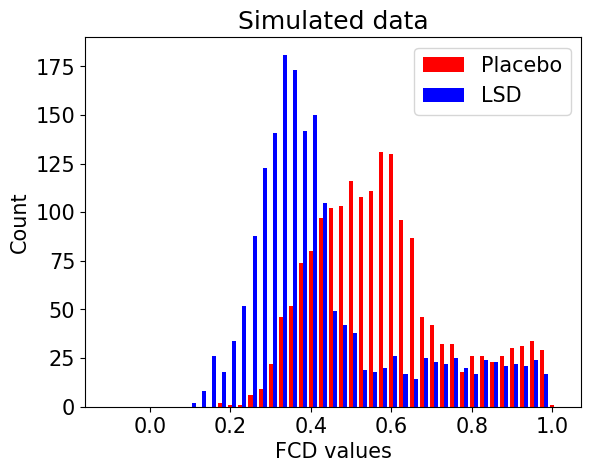

In [4]:
# Balance J for we=2.1 (cached by @loadOrCompute in BalanceFIC)
baseName = outFilePath + "/J_Balance_we2.1.mat"
balancedG = BalanceFIC.Balance_J9(2.1, C.shape[0], False, baseName)
serotonin2A.setParms(balancedG)
serotonin2A.setParms({'S_E': 0., 'S_I': 0.})

def simulate(NumSubjects):
    print("Subject:", 0)
    bds = simulateBOLD.simulateSingleSubject()
    cot = swFCD.from_fMRI(bds.T)
    cotsampling = np.zeros((NumSubjects, np.asarray(cot).size))
    cotsampling[0] = cot

    for nsub in range(1, NumSubjects):
        print("Subject:", nsub)
        bds = simulateBOLD.simulateSingleSubject()
        cotsampling[nsub] = swFCD.from_fMRI(bds.T)

    return cotsampling

# Placebo
pla_path = outFilePath + '/FCD_values_placebo.mat'
if not Path(pla_path).is_file():
    print("\nSIMULATION OF OPTIMAL PLACEBO")
    serotonin2A.setParms({'S_E': 0., 'S_I': 0.})
    cotsampling_pla_s = simulate(NumSubjects)
    sio.savemat(pla_path, {'cotsampling_pla_s': cotsampling_pla_s})
else:
    print("LOADING OPTIMAL PLACEBO")
    cotsampling_pla_s = sio.loadmat(pla_path)['cotsampling_pla_s']

# LSD
lsd_path = outFilePath + '/FCD_values_lsd.mat'
if not Path(lsd_path).is_file():
    print("\nSIMULATION OF OPTIMAL LSD fit")
    serotonin2A.setParms({'S_E': 0.34, 'S_I': 0.})
    cotsampling_lsd_s = simulate(NumSubjects)
    sio.savemat(lsd_path, {'cotsampling_lsd_s': cotsampling_lsd_s})
else:
    print("LOADING OPTIMAL LSD fit")
    cotsampling_lsd_s = sio.loadmat(lsd_path)['cotsampling_lsd_s']

# Plot
h_pla, _ = my_hist(cotsampling_pla_s.T.flatten(), bins)
h_lsd, _  = my_hist(cotsampling_lsd_s.T.flatten(), bins)
plaBar = plt.bar(x, h_pla, width=width, color="red", label="Placebo")
lsdBar = plt.bar(x + width, h_lsd, width=width, color="blue", label="LSD")
plt.xlabel('FCD values')
plt.ylabel('Count')
plt.legend(handles=[plaBar, lsdBar], loc='upper right')
plt.title('Simulated data')
plt.show()